In [32]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [33]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [34]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

min_range = -5_000
max_range = +0

anno = (
    anno
    .with_columns(
        encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
        encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
        encode_annotated = pl.col('not_in_encode') == False,
    )
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True)
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True))
        # (pl.col('non_mane_cds')==False)

        # Choose non CDS only
        ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False))

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True)
        # (pl.col('consequence_upstream_gene_variant') == True)
        # (pl.col('consequence_downstream_gene_variant') == True)
        # (pl.col('consequence_intron_variant') == True)

        # (pl.col('dist_to_tss') < max_range) &
        # (pl.col('dist_to_tss') > min_range)
        
        # Only Gene body
        # (pl.col('consequence_upstream_gene_variant')==0) &
        # (pl.col('consequence_downstream_gene_variant')==0)

        # Choose regulatory region
        # (pl.col('not_in_encode') == False)
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
    )
    
    # .with_columns(
    #     loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
    #     loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
    #     loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
    #     loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    # )
    .with_columns(
        indel_length = (pl.col('ref').str.len_chars() - pl.col('alt').str.len_chars()).abs(),
        insertion = pl.when(pl.col('ref').str.len_chars() < pl.col('alt').str.len_chars()).then(True).otherwise(False),
        deletion = pl.when(pl.col('ref').str.len_chars() > pl.col('alt').str.len_chars()).then(True).otherwise(False),
    )
    .with_columns(
        # --- Indel CDS categories ---
        deletion_x3bp = pl.when(pl.col('deletion') & (pl.col('indel_length') %3 == 0)).then(True).otherwise(False),
        deletion_not_x3bp = pl.when(pl.col('deletion') & (pl.col('indel_length') %3 != 0)).then(True).otherwise(False),
        insertion_x3bp = pl.when(pl.col('insertion') & (pl.col('indel_length') %3 == 0)).then(True).otherwise(False),
        insertion_not_x3bp = pl.when(pl.col('insertion') & (pl.col('indel_length') %3 != 0)).then(True).otherwise(False),

        # --- Indel length categories ---
        deletion_gt2bp = pl.when(pl.col('indel_length') >= 2).then(True).otherwise(False) & pl.col('deletion'),
        deletion_gt5bp = pl.when(pl.col('indel_length') >= 5).then(True).otherwise(False) & pl.col('deletion'),
        insertion_gt2bp = pl.when(pl.col('indel_length') >= 2).then(True).otherwise(False) & pl.col('insertion'),
        insertion_gt5bp = pl.when(pl.col('indel_length') >= 5).then(True).otherwise(False) & pl.col('insertion'),
    )
    .with_columns(
        # --- ENCODE indels ---
        encode_deletion = pl.when(pl.col('deletion') & (pl.col('encode_annotated')==True)).then(True).otherwise(False),
        encode_insertion = pl.when(pl.col('insertion') & (pl.col('encode_annotated')==True)).then(True).otherwise(False),
        encode_snp = pl.when((pl.col('encode_annotated')==True) & (pl.col('deletion')==False) & (pl.col('insertion')==False)).then(True).otherwise(False),

        # --- ENCODE deletions ---
        encode_deletion_gt2bp = pl.when((pl.col('indel_length') >= 2) & (pl.col('encode_annotated')==True)).then(True).otherwise(False) & pl.col('deletion'),
        encode_deletion_gt5bp = pl.when((pl.col('indel_length') >= 5) & (pl.col('encode_annotated')==True)).then(True).otherwise(False) & pl.col('deletion'),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

consequence_start_lost,gene_length,strand,insertion_x3bp,five_prime_utr_variant_consequence_uaug_lost,consequence_splice_acceptor_variant,encode_ca,insertion_gt2bp,deletion_gt5bp,five_prime_utr_variant_consequence_ustop_gained,consequence_stop_lost,consequence_missense_variant,mobi_lip_full,low_complexity_domain,encode_insertion,gene_name,id,encode_deletion_gt2bp,deletion_x3bp,region,non_mane_cds,insertion_gt5bp,insertion,five_prime_utr_variant_consequence_uaug_gained,ted_domain,consequence_splice_donor_variant,dist_to_tss,deletion_not_x3bp,not_in_encode,encode_dels,encode_pels,encode_all_tf,non_mane_exonic,insertion_not_x3bp,encode_ca_tf,encode_ca_h3k4me3,encode_tf,encode_eh_pr,encode_pls,tss,encode_deletion_gt5bp,loftee_lc,mobi_curated_disorder_priority,consequence_stop_gained,five_prime_utr_variant_consequence_uframeshift,mane_cds,loftee_hc,five_prime_utr_variant_consequence_ustop_lost,encode_snp,consequence_frameshift_variant,deletion,encode_deletion,mane_exonic,deletion_gt2bp,encode_annotated,encode_ca_ctcf
i32,i64,str,bool,u8,i32,bool,bool,bool,u8,i32,i32,bool,bool,bool,str,str,bool,bool,str,bool,bool,bool,u8,bool,i32,i64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,i64,bool,i8,bool,i32,u8,bool,i8,u8,bool,i32,bool,bool,bool,bool,bool,bool
0,290580,"""-1""",false,0,0,false,false,false,0,0,0,false,false,false,"""APP""","""chr21:26024903:C:A""",false,false,"""ENSG00000142192""",false,false,false,0,false,0,146225,false,true,false,false,false,false,false,false,false,false,false,false,26171128,false,0,false,0,0,false,0,0,false,0,false,false,false,false,false,false
0,198920,"""1""",false,0,0,false,false,false,0,0,0,false,false,false,"""ASAP2""","""chr2:9307877:C:T""",false,false,"""ENSG00000151693""",false,false,false,0,false,0,101113,false,false,true,false,false,false,false,false,false,false,true,false,9206764,false,0,false,0,0,false,0,0,true,0,false,false,false,false,true,false
0,83994,"""-1""",false,0,0,false,false,false,0,0,0,false,false,false,"""KDM5B""","""chr1:202731695:A:T""",false,false,"""ENSG00000117139""",false,false,false,0,false,0,76792,false,true,false,false,false,true,false,false,false,false,false,false,202808487,false,0,false,0,0,false,0,0,false,0,false,false,false,false,false,false
0,50975,"""-1""",false,0,0,false,false,false,0,0,0,false,false,false,"""PACC1""","""chr1:212407640:G:C""",false,false,"""ENSG00000065600""",false,false,false,0,false,0,7261,false,true,false,false,false,false,false,false,false,false,false,false,212414901,false,0,false,0,0,false,0,0,false,0,false,false,false,false,false,false
0,27871,"""1""",false,0,0,false,false,false,0,0,0,false,false,false,"""ERMAP""","""chr1:42841548:T:A""",false,false,"""ENSG00000164010""",false,false,false,0,false,0,24427,false,true,false,false,false,false,false,false,false,false,false,false,42817121,false,0,false,0,0,false,0,0,false,0,false,false,false,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,174752,"""1""",false,0,0,false,false,false,0,0,0,false,false,false,"""CGNL1""","""chr15:57400680:GGA:G""",false,false,"""ENSG00000128849""",false,false,false,0,false,0,24714,true,true,false,false,false,false,false,false,false,false,false,false,57375966,false,0,false,0,0,false,0,0,false,0,true,false,false,true,false,false
0,139574,"""1""",false,0,0,false,false,true,0,0,0,false,false,false,"""NFAT5""","""chr16:69628227:CTTCTCCCCACCACA…",false,false,"""ENSG00000102908""",false,false,false,0,false,0,63134,true,true,false,false,false,false,false,false,false,false,false,false,69565093,false,0,false,0,0,false,0,0,false,0,true,false,false,true,false,false
0,16296,"""-1""",true,0,0,false,true,false,0,0,0,false,false,false,"""PLIN4""","""chr19:4520392:G:GAAAAAAAAAAAAA…",false,false,"""ENSG00000167676""",false,true,true,0,false,0,-1906,false,true,false,false,false,false,false,false,false,false,false,false,4518486,false,0,false,0,0,false,0,0,false,0,false,false,false,false,false,f

In [35]:
selected_annos = anno_config_df.filter(
    # pl.col('category').is_in(['genomic_region']) # genomic_region
    # pl.col('category').is_in(['plof_consequences']) # plof consequences
    # pl.col('annotation').is_in(['loftee_hc', 'loftee_lc']) # loftee consequences

    # pl.col('category').is_in(['plof', 'missense']) # CDS
    # pl.col('category').is_in(['protein_domains']) # Protein Domains
    # pl.col('category').is_in(['loftee_protein_domains']) # LOFTEE Protein Domains

    # pl.col('category').is_in(['indel_cds']) # CDS indels
    # pl.col('category').is_in(['indel_categories']) # indel length
    # pl.col('category').is_in(['encode_indels']) # encode indels
    pl.col('category').is_in(['encode_deletions']) # encode deletions
    
    # pl.col('category').is_in(['encode_boolean']) # encode
    # pl.col('category').is_in(['encode_custom']) # encode custom regions
    # pl.col('category').is_in(['indel_categories', '5utr_annotator', 'encode_boolean']) # 5utr
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )   

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )
    .with_columns(
        # annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )

    # .drop_nulls()
    # .filter(pl.col('annotation_score').is_not_null())
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr21:26024903:C:A""","""ENSG00000142192""","""encode_snp""",0.0,"""encode_indels""",1,0.0
"""chr21:26024903:C:A""","""ENSG00000142192""","""encode_snp""",0.0,"""encode_deletions""",1,0.0
"""chr2:9307877:C:T""","""ENSG00000151693""","""encode_snp""",1.0,"""encode_indels""",1,1.0
"""chr2:9307877:C:T""","""ENSG00000151693""","""encode_snp""",1.0,"""encode_deletions""",1,1.0
"""chr1:202731695:A:T""","""ENSG00000117139""","""encode_snp""",0.0,"""encode_indels""",1,0.0
…,…,…,…,…,…,…
"""chr15:57400680:GGA:G""","""ENSG00000128849""","""encode_deletion_gt5bp""",0.0,"""encode_deletions""",1,0.0
"""chr16:69628227:CTTCTCCCCACCACA…","""ENSG00000102908""","""encode_deletion_gt5bp""",0.0,"""encode_deletions""",1,0.0
"""chr19:4520392:G:GAAAAAAAAAAAAA…","""ENSG00000167676""","""encode_deletion_gt5bp""",0.0,"""encode_deletions""",1,0.0


In [36]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [37]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

if pheno_list_type is not None:
    gene_trait_df = gene_trait_df.filter(pl.col('phenotype').is_in(pheno_list))

gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [38]:
n_steps = 101
or_threshold_pheno_left = 1
or_threshold_pheno_right = 1e-4

cutoffs_list = 1 - np.logspace(
    np.log10(or_threshold_pheno_left),
    np.log10(or_threshold_pheno_right),
    num=n_steps
)

pheno_cutoffs_lazy = pl.LazyFrame({"pheno_cutoff": cutoffs_list.tolist()})

pheno_cutoffs_lazy.collect()

pheno_cutoff
f64
0.0
0.087989
0.168236
0.241422
0.308169
…
0.999855
0.999868
0.99988


In [8]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    # Select required variants
    .join(
        anno_ids_lazy, 
        on="id", 
        how="semi"
    )
    # Merge annotation scores
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    # Merge with gene_trait_df
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1) # To get 1/100, 1/1000, etc.
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    
    # Cross join with cutoffs and compute odds ratios
    .join(
        pheno_cutoffs_lazy, 
        how="cross"
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "pheno_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor") == 1) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= pl.col("pheno_cutoff"))
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor") == 0) & 
            (pl.col("mean_pheno_value_dircor_ptile") < pl.col("pheno_cutoff"))
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = gp_lazy.collect(engine='streaming').sort('pheno_cutoff')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,pheno_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""encode_deletion_gt2bp""","""ENSG00000116183""","""PAPPA2""","""basal_metabolic_rate_int""",0.0,430,0,79865,0,NaN
"""encode_snp""","""ENSG00000025434""","""NR1H3""","""hdl_cholesterol_int""",0.0,4242,0,7630,0,NaN
"""encode_deletion_gt2bp""","""ENSG00000124257""","""NEURL2""","""hdl_cholesterol_int""",0.0,19,0,1767,0,NaN
"""encode_deletion_gt2bp""","""ENSG00000127585""","""FBXL16""","""hip_circumference_int""",0.0,94,0,6050,0,NaN
"""encode_deletion_gt2bp""","""ENSG00000146477""","""SLC22A3""","""lipoprotein_a_int""",0.0,136,0,20619,0,NaN
…,…,…,…,…,…,…,…,…,…
"""encode_deletion""","""ENSG00000178252""","""WDR6""","""trunk_predicted_mass_int""",0.9999,0,220,0,5582,NaN
"""encode_deletion_gt5bp""","""ENSG00000169047""","""IRS1""","""trunk_predicted_mass_int""",0.9999,0,65,2,15797,0.0
"""encode_snp""","""ENSG00000168769""","""TET2""","""white_blood_cell_leukocyte_cou…",0.9999,0,11238,2,46830,0.0


In [39]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['pheno_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['pheno_cutoff', 'annotation']),
        pheno_cutoff_inv = 1 - pl.col('pheno_cutoff'),
    )
    .with_columns(
        neg_log_pheno_cutoff_inv = -np.log10(pl.col('pheno_cutoff_inv')),
        med_odds_ratio = pl.col('odds_ratio').median().over(['pheno_cutoff_inv', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['pheno_cutoff_inv', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['pheno_cutoff_inv', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'neg_log_pheno_cutoff_inv', 'pheno_cutoff', 'pheno_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    
    # join plotting info
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('pheno_cutoff_inv')

    # Remove data points without ci or with or=0
    .filter(
        (pl.col('annotation')!='core_promoter') &
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 10) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str
"""encode_snp""",4.0,0.9999,0.0001,697,0.500783,1.116865,0.069145,1.252389,0.98134,"""peru""","""ENCODE annotated SNP"""
"""encode_snp""",4.0,0.9999,0.0001,697,0.500783,1.116865,0.069145,1.252389,0.98134,"""peru""","""ENCODE annotated SNP"""
"""encode_deletion_gt5bp""",4.0,0.9999,0.0001,813,0.0,1.100343,0.405066,1.894273,0.306414,"""#C7E9C0""","""ENCODE region Deletion (>=5bp)"""
"""encode_deletion_gt2bp""",4.0,0.9999,0.0001,809,0.0,0.822588,0.196295,1.207326,0.43785,"""#41AB5D""","""ENCODE region Deletion (>=2bp)"""
"""encode_deletion""",4.0,0.9999,0.0001,803,0.0,0.852165,0.165699,1.176935,0.527394,"""#005A32""","""ENCODE annotated Deletion"""
…,…,…,…,…,…,…,…,…,…,…,…
"""encode_deletion""",0.04,0.087989,0.912011,1176,1.007262,1.060087,0.008759,1.077255,1.042919,"""#238B45""","""ENCODE region Deletion"""
"""encode_deletion_gt2bp""",0.04,0.087989,0.912011,1170,1.010735,1.113791,0.014241,1.141704,1.085878,"""#41AB5D""","""ENCODE region Deletion (>=2bp)"""
"""encode_snp""",0.04,0.087989,0.912011,1176,1.002258,1.010612,0.002597,1.015702,1.005522,"""peru""","""ENCODE annotated SNP"""


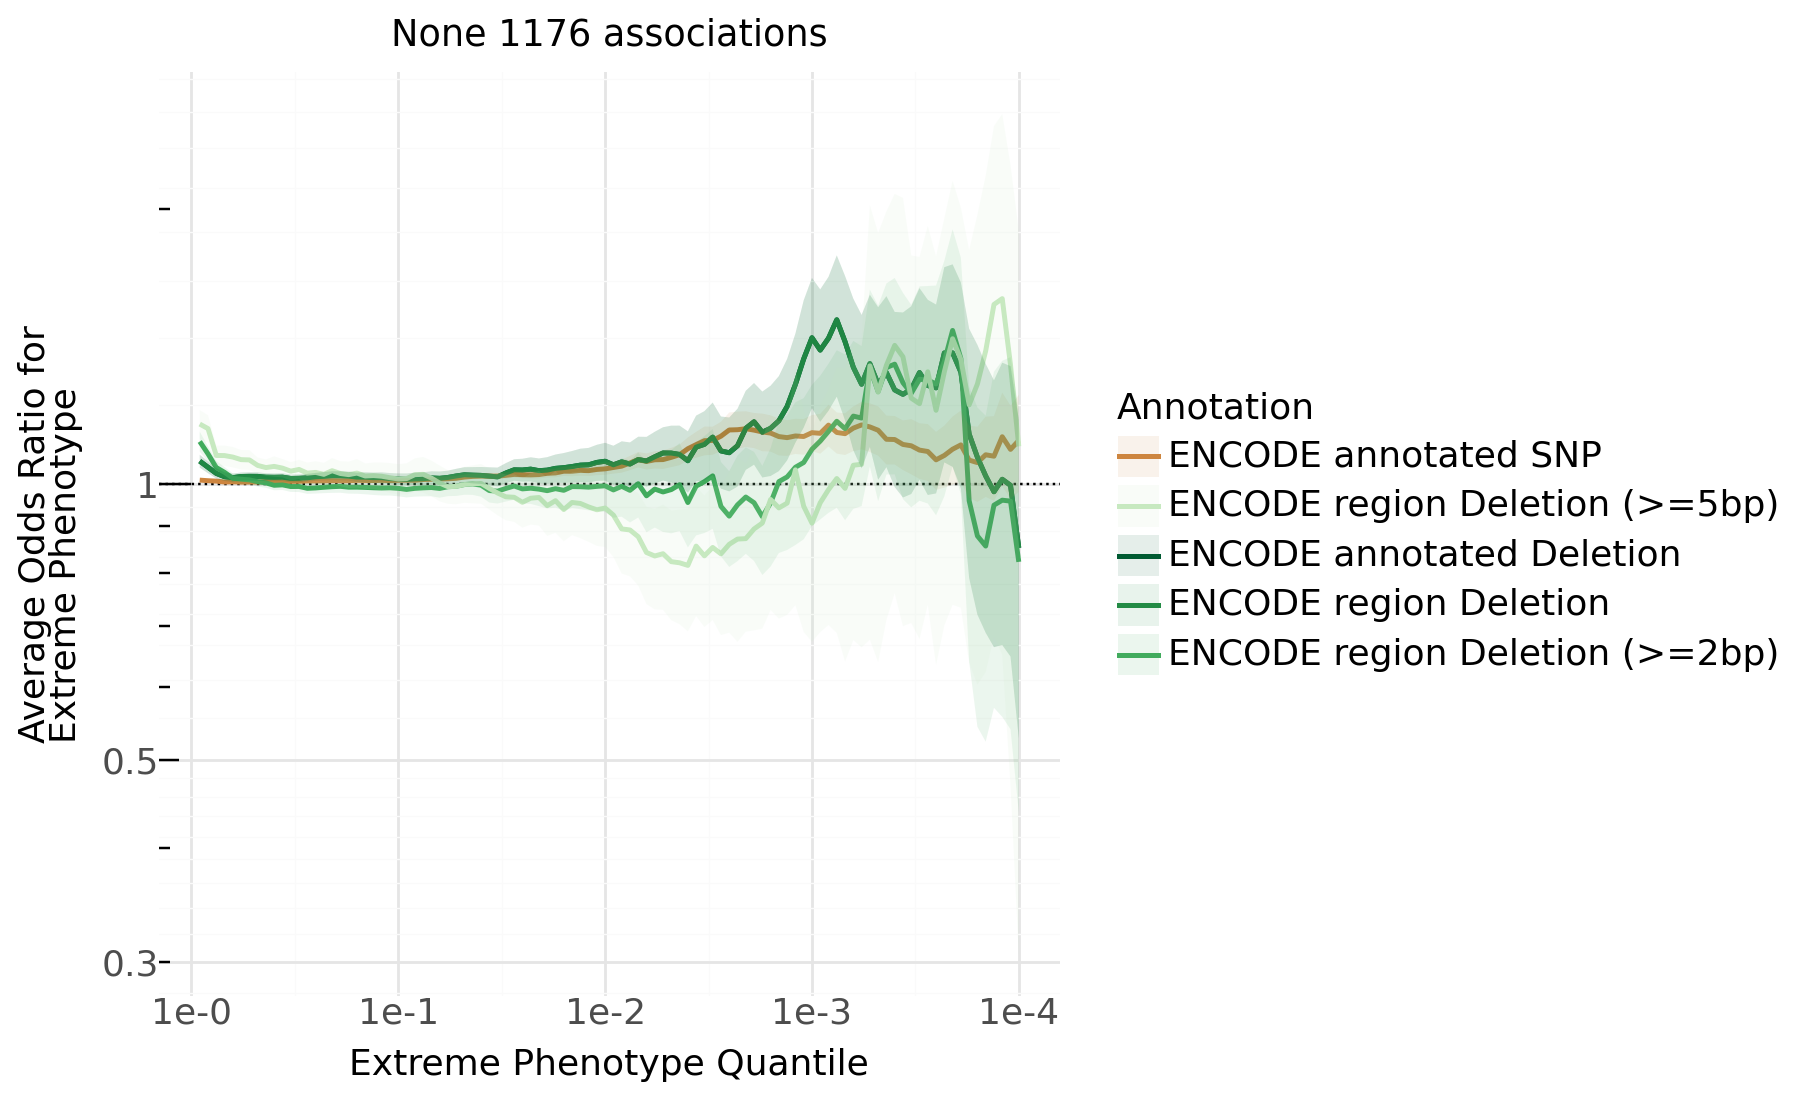

In [40]:
# Determine legend order based on final average odds ratio
legend_order = (
    plt_df.sort("neg_log_pheno_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

# Generate breaks and labels for x-axis
start_exp = int(-np.log10(or_threshold_pheno_left))
end_exp = int(-np.log10(or_threshold_pheno_right))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e-{b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plt_df,
        aes(x='neg_log_pheno_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        title=f"{pheno_list_type} {or_df[['gene_name', 'phenotype']].unique().shape[0]} associations",
        y=f"Average Odds Ratio for\nExtreme Phenotype",
        x="Extreme Phenotype Quantile",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="l")
    + theme_minimal()
    + theme(
        figure_size=(9, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [41]:
plt_df.filter(
    (pl.col('pheno_cutoff')==0.99) &
    (pl.col('annotation').is_in(['loftee_hc']))
)

annotation,neg_log_pheno_cutoff_inv,pheno_cutoff,pheno_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,f64,f64,u64,f64,f64,f64,f64,f64,str,str


In [42]:
melted_anno.filter(
    (pl.col('annotation')=='loftee_hc') &
    (pl.col('annotation_score_dircor')==1)
)

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
